# 3. Tides and open boundaries

**What this shows:** how rompy-schism turns a tidal model into SCHISM's boundary
conditions, what `bctides.in` contains, and how well the model reproduces the tide it
is forced with.

**Prerequisites:** [Tutorial 2: The mesh and the vertical grid](02_mesh_and_vertical_grid.ipynb).

**You will learn:**

- how `TidalDataset` selects tidal constituents from a tidal database
- what the four boundary flags in `bctides.in` mean, and how to set them for each
  open boundary
- what nodal corrections and the tidal potential do
- the difference between forcing the boundary with tidal elevations only and with
  elevations and currents

**Data used:** `hgrid.gr3` and `tides/`, TPXO9 constituents around Perth.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pyTMD
import timescale.time
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.data import DataBlob
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_schism.boundary_core import TidalDataset
from rompy_schism.config import SCHISMConfig
from rompy_schism.data import (
    BoundarySetupWithSource,
    SCHISMData,
    SCHISMDataBoundaryConditions,
)
from rompy_schism.grid import SCHISMGrid
from rompy_schism.namelists import NML, Param

logging_config.update(level="ERROR")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "03_tides_and_open_boundaries"
shutil.rmtree(OUT_DIR, ignore_errors=True)

SCHISM_IMAGE = "ghcr.io/rom-py/schism:5.13.0"
CONSTITUENTS = ["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"]
grid = SCHISMGrid(hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"), drag=0.0025)

## 1. Tidal constituents

A tide is a sum of harmonic constituents, each with a known frequency and, at every
place, an amplitude and a phase. Global tidal models such as
[TPXO](https://www.tpxo.net) and [FES](https://www.aviso.altimetry.fr) provide
them on a grid. rompy-schism reads them with [pyTMD](https://pytmd.readthedocs.io),
through a database file, `database.json`, that says where the files are and in which
format. The example database has the eight main constituents of TPXO9 around Perth.

In [2]:
print((DATA_DIR / "tides" / "database.json").read_text()[:600])

{
  "elevation": {
    "TPXO9-perth": {
      "format": "ATLAS-netcdf",
      "grid_file": "tpxo9-perth/grid_tpxo9.nc",
      "name": "TPXO9-perth",
      "projection": "EPSG:4326",
      "scale": 1,
      "reference": "https://www.tpxo.net/global",
      "version": "v5a",
      "model_file": [
        "tpxo9-perth/h_m2_tpxo9.nc",
        "tpxo9-perth/h_s2_tpxo9.nc",
        "tpxo9-perth/h_n2_tpxo9.nc",
        "tpxo9-perth/h_k2_tpxo9.nc",
        "tpxo9-perth/h_k1_tpxo9.nc",
        "tpxo9-perth/h_o1_tpxo9.nc",
        "tpxo9-perth/h_p1_tpxo9.nc",
        "tpxo9-perth/h_q1_tpxo9.nc"
      ],



The amplitudes show the character of the tide here: the diurnal constituents K1 and
O1, which rise and fall once a day, are larger than the semidiurnal M2 and S2. The
TPXO grid is coarse, 1/6°, so it gives only the large-scale tide at the open boundary;
SCHISM computes the detail inside.

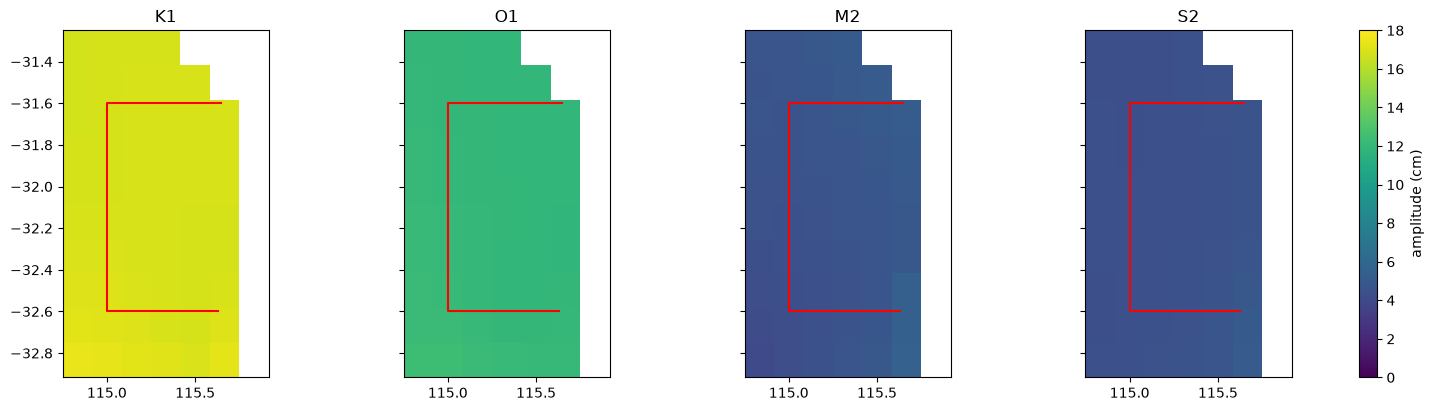

In [3]:
atlas = DATA_DIR / "tides" / "tpxo9-perth"
tpxo_grid = xr.open_dataset(atlas / "grid_tpxo9.nc")
hgrid = grid.pylibs_hgrid
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True, layout="constrained")
for ax, name in zip(axes, ["k1", "o1", "m2", "s2"]):
    constituent = xr.open_dataset(atlas / f"h_{name}_tpxo9.nc")
    amplitude = np.abs(constituent.hRe + 1j * constituent.hIm).where(tpxo_grid.hz > 0)
    mesh = ax.pcolormesh(
        tpxo_grid.lon_z, tpxo_grid.lat_z, amplitude.T * 100, cmap="viridis",
        vmin=0, vmax=18,
    )  # fmt: skip
    ax.plot(hgrid.x[hgrid.iobn[0]], hgrid.y[hgrid.iobn[0]], "r", linewidth=1.5)
    ax.set(title=name.upper(), aspect=1 / np.cos(np.radians(32)))
fig.colorbar(mesh, ax=axes, label="amplitude (cm)")

`TidalDataset` chooses the database, the model within it and the constituents. Two
options matter for accuracy:

- **Nodal corrections** (`nodal_corrections`): the amplitude and phase of each
  constituent vary slightly over the 18.6-year lunar nodal cycle. With corrections, the
  boundary tide is right for the run's dates. They are off by default.
- **Tidal potential** (`tidal_potential`): the tide-generating force acts on the water
  inside the domain too, not only at the boundary. It matters for large domains and
  is applied only where the water is deeper than `cutoff_depth` (50 m by default).

In [4]:
tides = TidalDataset(
    tidal_database=DATA_DIR / "tides",
    tidal_model="TPXO9-perth",
    constituents=CONSTITUENTS,
    nodal_corrections=True,
    tidal_potential=True,
)

## 2. What each open boundary does

`bctides.in` has one entry per open boundary of the mesh, with four flags: elevation,
velocity, temperature and salinity. The most common values:

| Flag | Elevation | Velocity | Temperature, salinity |
|---|---|---|---|
| 0 | not set | not set | not set |
| 2 | constant | constant discharge (e.g. a river) | constant |
| 3 | tidal constituents | tidal constituents | initial values, nudged |
| 4 | from a file, `elev2D.th.nc` | from a file, `uv3D.th.nc` | from a file, `TEM_3D.th.nc`, `SAL_3D.th.nc` |
| 5 | tides plus the file | tides plus the file | |
| -1 | | Flather radiation | |

`BoundarySetupWithSource` sets them for one boundary. `boundaries` gives a setup per
open boundary, by its index in `hgrid.gr3`; `default_boundary` applies to the others.
The [SCHISM manual](https://schism-dev.github.io/schism/master/input-output/bctides.html)
lists every option. [Ocean boundaries](../examples/ocean_boundaries.ipynb) uses the
file types.

Every open boundary needs a setup. This mesh has one, so a setup for a second one is
an error:

In [5]:
tidal = BoundarySetupWithSource(elev_type=3, vel_type=3)
try:
    SCHISMDataBoundaryConditions(tidal_data=tides, boundaries={1: tidal}).get(
        OUT_DIR / "check", grid, TimeRange(start="2023-01-01", end="2023-01-02", interval="1h")
    )
except ValueError as err:
    print(err)

boundaries [1] are not open boundaries of the mesh, which has 1 (indices 0 to 0)


## 3. The boundary file

Two runs, both from 1 to 4 January: one forced with tidal elevations only (`3 0`),
one with elevations and currents (`3 3`).

In [6]:
period = TimeRange(start="2023-01-01T00:00", end="2023-01-04T00:00", interval="1h")
nml = NML(
    param=Param(
        core={"ibc": 1, "ibtp": 0, "dt": 120.0, "nspool": 30, "ihfskip": 720},
        schout={"iof_hydro__1": 1, "iof_hydro__16": 1, "iof_hydro__26": 0},
    )
)
setups = {
    "elevation": BoundarySetupWithSource(elev_type=3, vel_type=0),
    "elevation_and_currents": BoundarySetupWithSource(elev_type=3, vel_type=3),
}
workspaces = {}
for name, setup in setups.items():
    data = SCHISMData(
        boundary_conditions=SCHISMDataBoundaryConditions(
            tidal_data=tides, default_boundary=setup
        )
    )
    config = SCHISMConfig(grid=grid, data=data, nml=nml)
    run = ModelRun(run_id=name, period=period, output_dir=OUT_DIR, config=config)
    workspaces[name] = (run, Path(run()))

The start of `bctides.in`: the tidal potential (constituent, species, equilibrium
amplitude, frequency, nodal factor and equilibrium argument), then the constituents at
the boundary with their frequencies, nodal factors and arguments for 1 January 2023.

In [7]:
bctides = (workspaces["elevation_and_currents"][1] / "bctides.in").read_text()
print("\n".join(bctides.splitlines()[:22]))

!01/01/2023 00:00:00 UTC
 8 50.000 !number of earth tidal potential, cut-off depth for applying tidal potential
m2
2 0.244100 1.405189e-04 0.971878 146.116550
s2
2 0.112743 1.454441e-04 1.000000 0.000000
n2
2 0.046397 1.378797e-04 0.971878 58.671228
k2
2 0.030684 1.458423e-04 1.245126 190.029138
k1
1 0.141565 7.292116e-05 1.092313 5.278619
o1
1 0.100661 6.759774e-05 1.149276 142.971055
p1
1 0.046848 7.252295e-05 1.000000 349.602562
q1
1 0.019273 6.495854e-05 1.150002 55.749367
9 !nbfr
z0
0.0 1.0 0.0
m2


The first constituent at the boundary, `z0`, is not a tide: it is a constant offset,
the mean dynamic topography of `TidalDataset` (zero here; [Tidal boundaries](../examples/tidal_boundaries.ipynb)
sets it). Then comes the open boundary: its number of nodes and flags, and the
amplitude (m) and phase (degrees) of each constituent at each node. With
`vel_type=3` the same follows for the east and north components of the tidal
current.

In [8]:
lines = bctides.splitlines()
start = next(i for i, line in enumerate(lines) if "!nope" in line)
print("\n".join(lines[start : start + 6]))

1 !nope
115 3 3 0 0 !open boundary 1
z0
0.000000 0.0
0.000000 0.0
0.000000 0.0


## 4. Run both

SCHISM runs in the public Docker image; the run is checked in SCHISM's log, since
SCHISM returns success even when it stops on an error.

In [9]:


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


def run_completed(workspace: Path) -> bool:
    """Check SCHISM's log: SCHISM exits with success even when it stops on an error."""
    mirror = workspace / "outputs" / "mirror.out"
    if mirror.exists() and "Run completed successfully" in mirror.read_text():
        return True
    fatal = workspace / "outputs" / "fatal.error"
    print(fatal.read_text() if fatal.exists() else "SCHISM did not finish")
    return False


backend = DockerConfig(image=SCHISM_IMAGE, executable="schism 2", mpiexec="mpirun", cpu=6)
results = {}
for name, (run, workspace) in workspaces.items():
    if docker_available():
        run.run(backend, workspace_dir=workspace)
    if run_completed(workspace):
        results[name] = xr.open_mfdataset(
            sorted((workspace / "outputs").glob("out2d_*.nc")),
            data_vars="minimal", coords="minimal", compat="override",
        )  # fmt: skip
print(f"Completed: {list(results)}")

Completed: ['elevation', 'elevation_and_currents']


## 5. Compare with the tide prediction

pyTMD predicts the tide at any point from the same constituents. Near the open
boundary, the model should follow it closely; elsewhere, SCHISM's own dynamics and
its finer mesh make the difference.

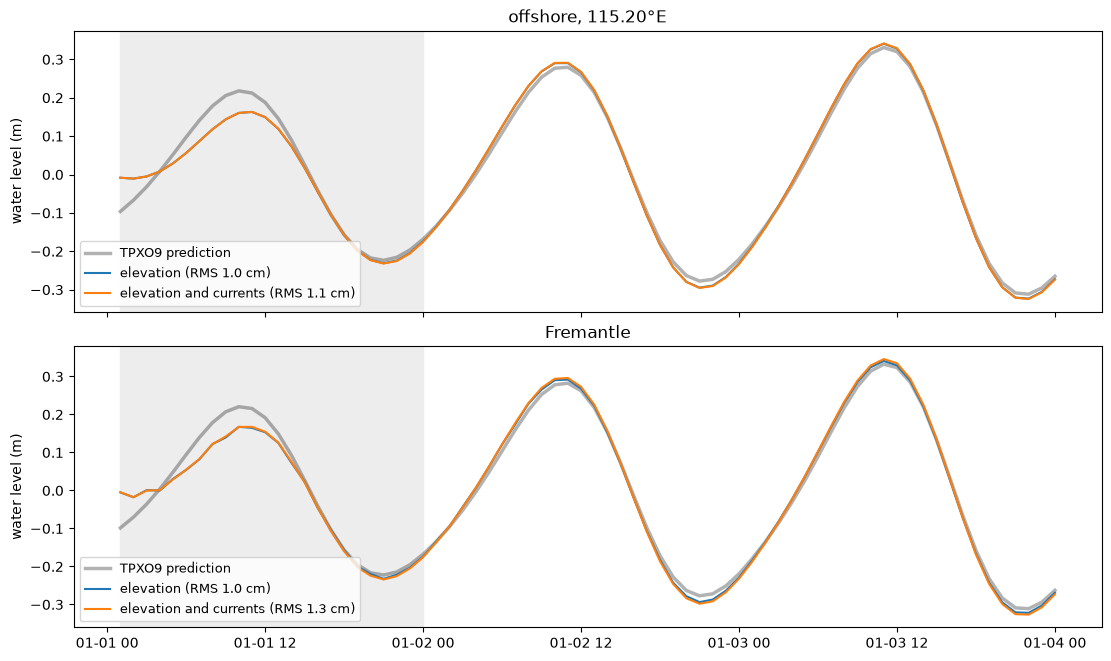

In [10]:


def predicted_tide(lon: float, lat: float, times: np.ndarray) -> np.ndarray:
    """Tide at one point from the TPXO9 constituents, with nodal corrections."""
    database = DATA_DIR / "tides"
    model = pyTMD.io.model(database, extra_databases=[database / "database.json"])
    names = [c.lower() for c in CONSTITUENTS]
    amplitude, phase, _ = model.elevation("TPXO9-perth").extract_constants(
        np.array([lon]), np.array([lat]), constituents=names, method="bilinear"
    )
    constants = amplitude * np.exp(-1j * np.radians(phase))
    ts = timescale.time.Timescale().from_datetime(times.astype("datetime64[s]"))
    return np.asarray(
        pyTMD.predict.time_series(
            ts.tide, constants, names, deltat=ts.tt_ut1, corrections="OTIS"
        )
    ).squeeze()


points = {"offshore, 115.20°E": (115.20, -32.10), "Fremantle": (115.72, -32.06)}
if results:
    out2d = next(iter(results.values()))
    x = out2d.SCHISM_hgrid_node_x.values
    y = out2d.SCHISM_hgrid_node_y.values
    times = out2d.time.values
    after_ramp = times >= np.datetime64("2023-01-02")
    fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, layout="constrained")
    for ax, (label, (lon, lat)) in zip(axes, points.items()):
        node = np.argmin((x - lon) ** 2 + (y - lat) ** 2)
        tide = predicted_tide(x[node], y[node], times)
        ax.plot(times, tide, "k", linewidth=2.5, alpha=0.3, label="TPXO9 prediction")
        for name, out in results.items():
            level = out.elevation[:, node].values
            rms = np.sqrt(np.mean((level - tide)[after_ramp] ** 2)) * 100
            ax.plot(times, level, label=f"{name.replace('_', ' ')} (RMS {rms:.1f} cm)")
        ax.axvspan(times[0], np.datetime64("2023-01-02"), color="0.93")
        ax.set(title=label, ylabel="water level (m)")
        ax.legend(loc="lower left", fontsize=9)

Both runs follow the prediction closely after the one-day ramp (grey). Here the two
settings give nearly the same water levels, because the tidal currents are weak. On
coasts with strong tidal currents, prescribing both elevation and currents is often
more accurate, although the two can then conflict and need consistent data.

## Summary

- `TidalDataset` selects the constituents from a pyTMD tidal database; enable
  `nodal_corrections` for the tide of the run's dates.
- Each open boundary has four flags; set them with `boundaries` by index, and
  `default_boundary` for the rest. Every open boundary needs one.
- `bctides.in` holds the constituents' frequencies and, for each boundary node, their
  amplitudes and phases, computed for the start of the run.
- SCHISM ramps the forcing up over `dramp` days (1 by default); leave the ramp out of
  any analysis.

**Next:** [4. Atmospheric forcing](04_atmospheric_forcing.ipynb).